In [3]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

from sv3.nn import FunctionalModelJac, MLP
from sv3.svd_sgd import SVDOptimizer

import sys
sys.path.append('..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: mps


In [4]:
from torchvision import datasets, transforms
from experiments.datasets import MNISTDataset

mnist = MNISTDataset(ROOT='../notebooks/datasets/')
train_dataset = mnist.train_dataset
test_dataset = mnist.val_dataset

In [6]:
mlp_base = MLP(
    input_dim=784,
    hidden_dims=[32,32,32],
    output_dim=10
)
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

LOADER_SEED = 645297
batch_size = 64
n_epoch = 5

METHODS = ["randomized","lobpcg"]
K_VALS = [16]

### Train MLP with Adam

In [7]:
model_adam = MLP(input_dim=784, hidden_dims=[32,32,32], output_dim=10)
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

optimizer = torch.optim.Adam(model_adam.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

train_loader = DataLoader(mnist.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(mnist.val_dataset, batch_size=256, shuffle=False)

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

Using device mps


100%|██████████| 5/5 [00:16<00:00,  3.33s/it]


### Train MLP with Sven

In [10]:
device = 'cpu'
model_svd = MLP(input_dim=784, hidden_dims=[32,32,32], output_dim=10)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    fn = torch.nn.CrossEntropyLoss(reduction='none')
    loss = fn(pred, y).squeeze()
    return loss

RTOL = 1e-2
LR = 0.1
K = 32

model_svd = FunctionalModelJac(model_svd, loss_fn, device=device)
optimizer = SVDOptimizer(model_svd,lr=LR,k=K,rtol=RTOL,track_svd_info=True,svd_mode='randomized')


train_loader = DataLoader(mnist.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED),drop_last=True)
test_loader = DataLoader(mnist.val_dataset, batch_size=256, shuffle=False)

model_svd, losses_svd, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer.svd_info

torch.compiler.reset()

100%|██████████| 5/5 [02:53<00:00, 34.72s/it]


### Compare

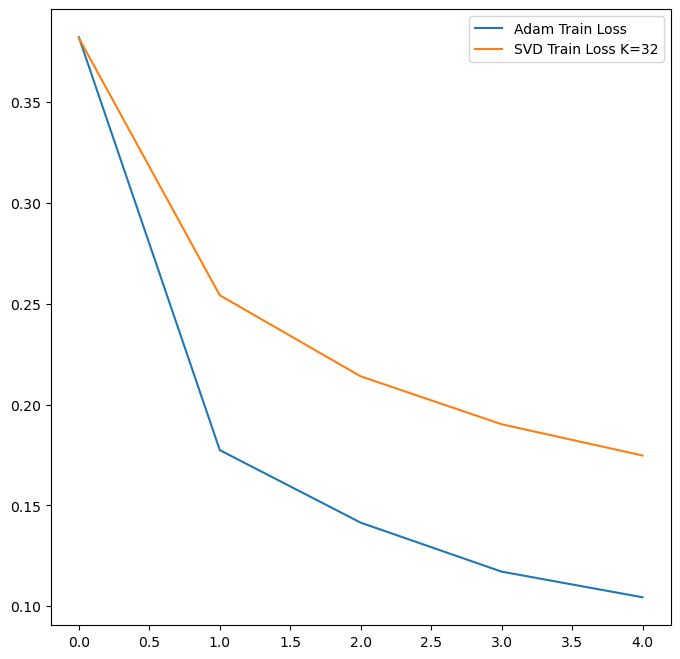

In [11]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['train'])), losses_adam['train'], label='Adam Train Loss')
ax.plot(np.arange(len(losses_svd['train'])), losses_svd['train'], label=f'SVD Train Loss K={K}')
plt.legend()

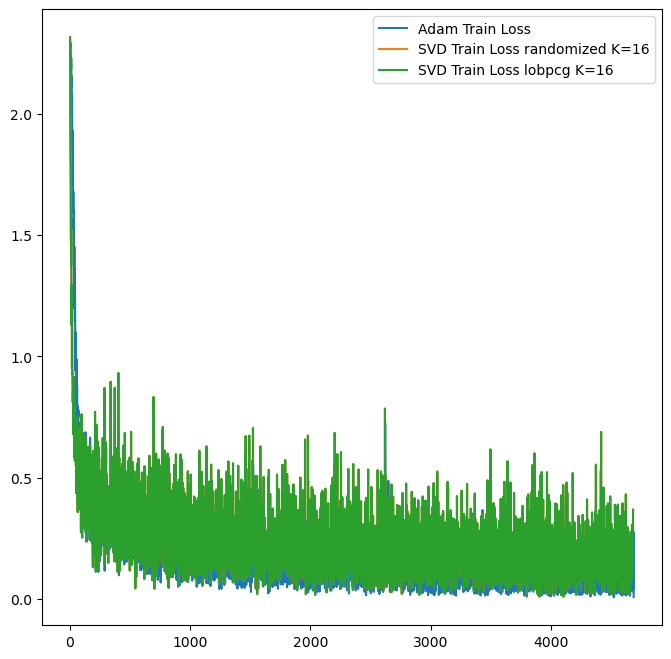

In [12]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['train_batch'])), losses_adam['train_batch'], label='Adam Train Loss')
for METHOD in METHODS:
    for K in K_VALS:
        ax.plot(np.arange(len(losses_svd['train_batch'])), losses_svd['train_batch'], label=f'SVD Train Loss {METHOD} K={K}')
plt.legend()

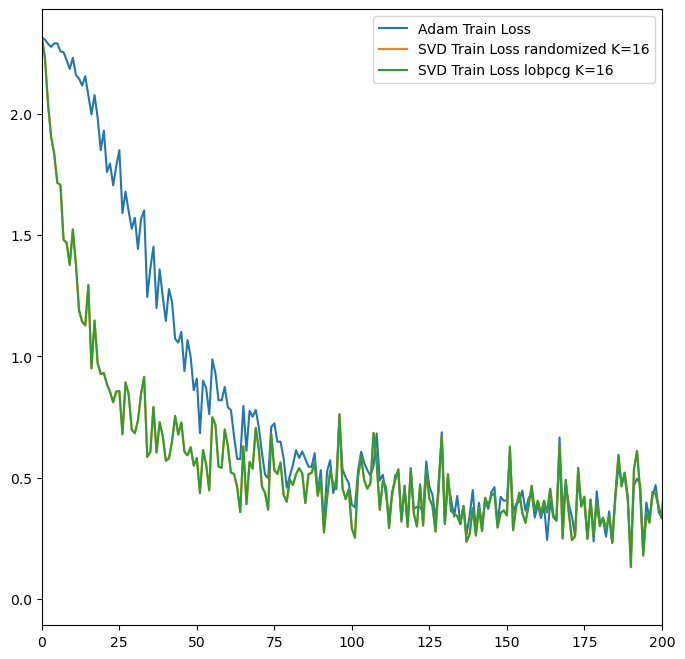

In [13]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['train_batch'])), losses_adam['train_batch'], label='Adam Train Loss')
for METHOD in METHODS:
    for K in K_VALS:
        ax.plot(np.arange(len(losses_svd['train_batch'])), losses_svd['train_batch'], label=f'SVD Train Loss {METHOD} K={K}')
ax.set_xlim(0,200)
plt.legend()

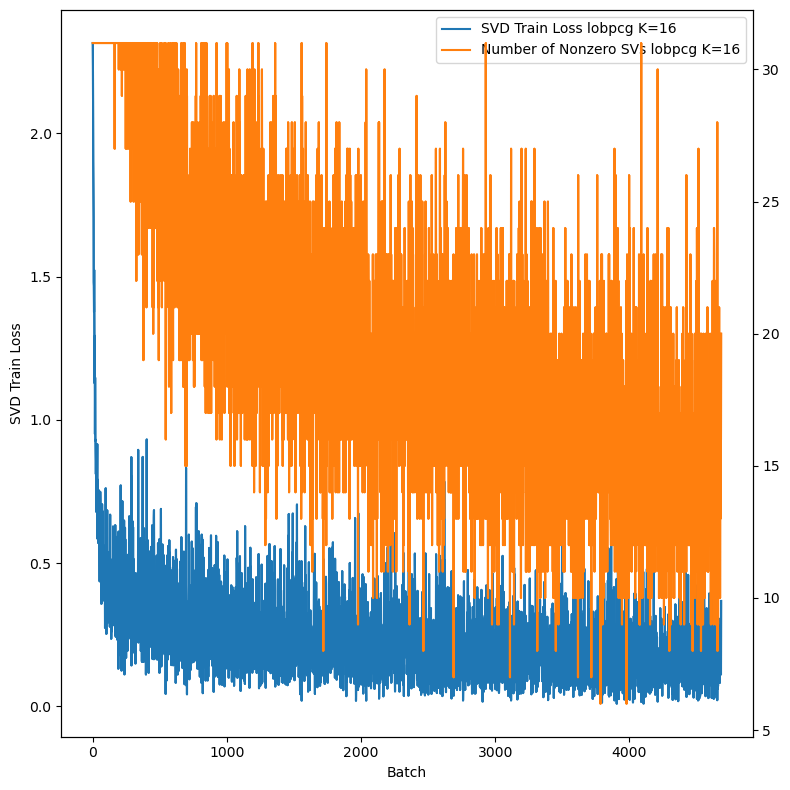

In [14]:
fig, ax1 = plt.subplots(figsize=(8,8))

plots = []
for METHOD in METHODS:
    for K in K_VALS:
        p1 = ax1.plot(np.arange(len(losses_svd['train_batch'])), losses_svd['train_batch'], 'C0', label=f'SVD Train Loss {METHOD} K={K}')
        plots.append(p1[0])
ax1.set_xlabel('Batch')
ax1.set_ylabel('SVD Train Loss')
ax1.legend()

ax2 = ax1.twinx()
for METHOD in METHODS:
    for K in K_VALS:
        p2 = ax2.plot(np.arange(len(svd_info['num_nonzero_svs'])), svd_info['num_nonzero_svs'], 'C1-',label=f'Number of Nonzero SVs {METHOD} K={K}')

ax1.legend(handles=[p1[0],p2[0]])
plt.tight_layout()

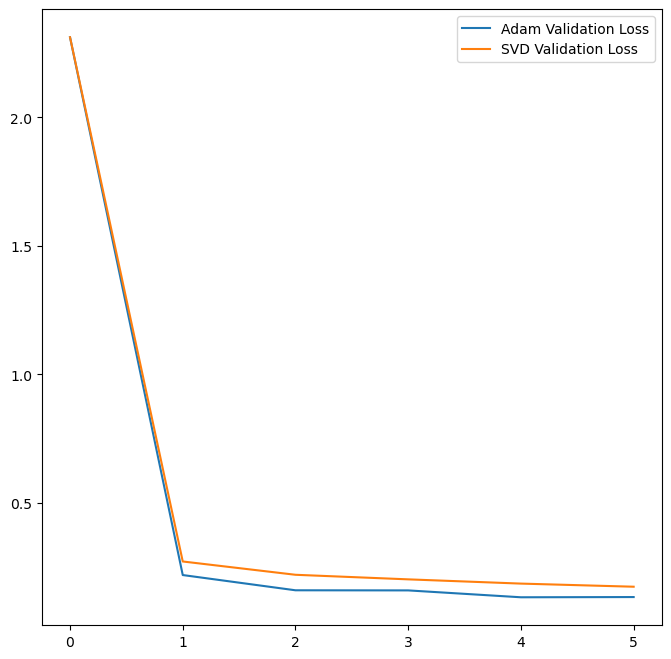

In [15]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['val'])), losses_adam['val'], label='Adam Validation Loss')
ax.plot(np.arange(len(losses_svd['val'])), losses_svd['val'], label='SVD Validation Loss')
plt.legend()

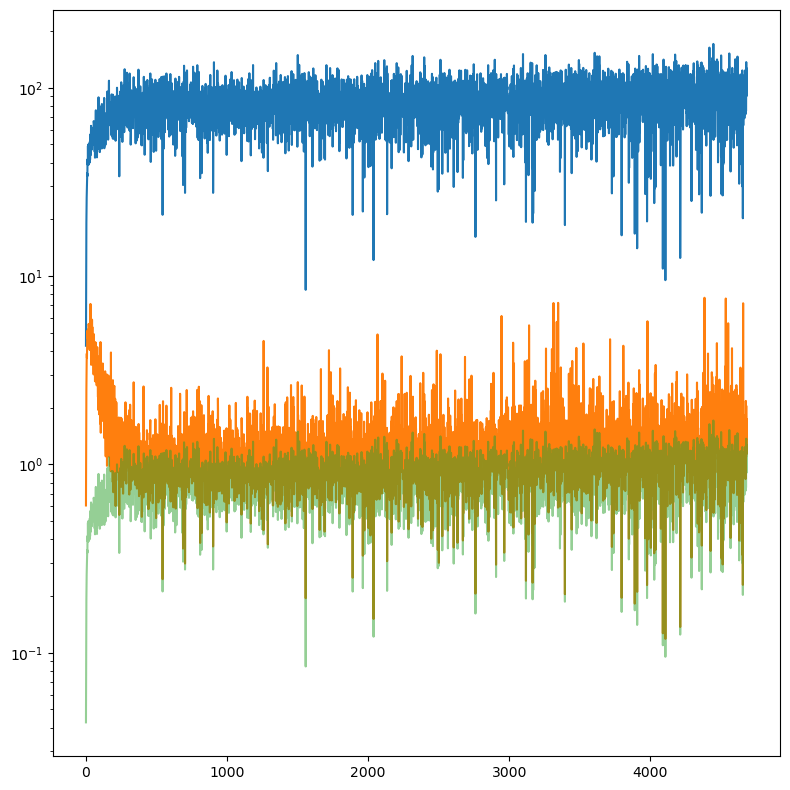

In [16]:
fig,ax = plt.subplots(figsize=(8,8))

n_batches = len(svd_info['num_nonzero_svs'])
p = ax.plot(np.arange(n_batches),[sv[0] for sv in svd_info['svs']],label='Top Singular Value')
p2 = ax.plot(np.arange(n_batches), [sv[-1] for sv in svd_info['svs']])
p = ax.plot(np.arange(n_batches),[RTOL*sv[0] for sv in svd_info['svs']],label='Top Singular Value',alpha=0.5)
plt.yscale('log')

plt.tight_layout()